In [11]:
import ast
import json
import logging
import os

import matplotlib.pyplot as plt
import pandas as pd

from doc_chat.rag.multi_tenant_vector_store import MultiTenantVectorStore, \
    VectorStoreDocument
from doc_chat.rag.reranker import Reranker

logging.getLogger("httpx").setLevel(logging.WARNING)

In [3]:
# set the number of files to process, None means all files
number_of_articles = 10
file_path = '../../data/squad/raw/train-v1.1.json'

results_directory = '../../data/squad/results'
if not os.path.exists(results_directory):
    os.makedirs(results_directory)

In [4]:
chroma_persist_directory = '/Users/patrick/projects/doc-chat/app_data/chroma_eval'


class Split:
    def __init__(self, content, page=0):
        self.page_content = content
        self.metadata = {"page": page}


if not os.path.exists(chroma_persist_directory):
    os.makedirs(chroma_persist_directory)
user_id = 'squad_semantic_search_text_embedding_3_small'
vector_store = MultiTenantVectorStore(chroma_persist_directory=chroma_persist_directory,
                                      embedding_model='text-embedding-3-small')

Using Chroma persist directory: /Users/patrick/projects/doc-chat/app_data/chroma_eval


In [32]:
# index the articles
with open(file_path, 'r') as f:
    squad_data = json.load(f)

print('Number of articles:', len(squad_data['data']))
articles = squad_data['data']

for article_idx, article in enumerate(articles):
    if number_of_articles and article_idx >= number_of_articles:
        break
    title = article['title']
    paragraphs = article['paragraphs']
    document_splits = []
    for p_idx, paragraph in enumerate(paragraphs):
        context = paragraph['context']
        document_splits.append(Split(content=context, page=p_idx))

    print(f"Indexing {len(document_splits)} chunks for article '{title}'")
    collection_id = f"article_{article_idx}"

    if vector_store.collection_exists(user_id=user_id, collection_id=collection_id):
        print(f"Collection '{collection_id}' already exists, deleting it.")
        vector_store.delete_collection(user_id=user_id, collection_id=collection_id)

    vector_store.create_document_collection(user_id=user_id,
                                            collection_id=collection_id,
                                            document_splits=document_splits,
                                            file_name=title)

collections = vector_store.get_collections(user_id=user_id)
print(collections)

Number of articles: 442
Indexing 55 chunks for article 'University_of_Notre_Dame'
Collection 'article_0' already exists, deleting it.
['article_0', 'article_3', 'article_6', 'article_4', 'article_8', 'article_5', 'article_9', 'article_2', 'article_7', 'article_1']


In [40]:
# query the vector store

top_k = 20  # number of documents to retrieve

reranker = Reranker(max_length=256)


def mean_reciprocal_rank(retrieved_docs, doc_id):
    for doc_idx, doc in enumerate(retrieved_docs):
        if doc.id == doc_id:
            return 1 / (doc_idx + 1)
    return 0.0


def recall_at_k(retrieved_docs, doc_id):
    return 1 if any(doc.id == doc_id for doc in retrieved_docs) else 0


with open(file_path, 'r') as f:
    squad_data = json.load(f)

articles = squad_data['data']
data = []  # to store the results

for article_idx, article in enumerate(articles):
    if number_of_articles and article_idx >= number_of_articles:
        break
    title = article['title']
    collection_id = f"article_{article_idx}"
    paragraphs = article['paragraphs']

    print(f"Processing article '{title}' with {len(paragraphs)} paragraphs and collection ID '{collection_id}'")

    for p_idx, paragraph in enumerate(paragraphs):
        qas = paragraph['qas']
        for qa in qas:
            question = qa['question']
            question_id = qa['id']
            expected_doc_id = f"doc_{p_idx}"

            #print(f"Querying for question: '{question}' in article '{title}'")
            documents: list[VectorStoreDocument] = vector_store.retrieve_documents(user_id=user_id,
                                                                                   collection_id=collection_id,
                                                                                   query=question, k=top_k)
            # How high the correct doc ranks in top-k
            mrr = mean_reciprocal_rank(documents, expected_doc_id)

            # Whether the correct doc is found in top-k
            recall = recall_at_k(documents, expected_doc_id)

            # rerank the documents
            ranked_documents = reranker.rerank(query=question, documents=documents)

            # How high the correct doc ranks in top-k after reranking
            mrr_ranked = mean_reciprocal_rank(ranked_documents, expected_doc_id)

            # Whether the correct doc is found in top-k after reranking
            recall_ranked = recall_at_k(ranked_documents, expected_doc_id)

            data.append({
                'question_id': question_id,
                'article': title,
                'expected_doc_id': expected_doc_id,
                'retrieved_docs': [doc.id for doc in documents],
                'ranked_docs': [doc.id for doc in ranked_documents],
                'mrr': mrr,
                'mrr_ranked': mrr_ranked,
                'recall': recall,
                'recall_ranked': recall_ranked,
                'top_k': top_k,
                'number_of_paragraphs': len(paragraphs),
            })
            # print(f"Expected: {expected_doc_id}, found: {[doc.id for doc in documents]}")
            # print(f"Recall: {recall}, Precision: {mrr:.2f}")
            # print()

results_df = pd.DataFrame(data)
results_df.to_csv(f'{results_directory}/results_top_{top_k}_small_embed.csv', index=False)

Processing article 'University_of_Notre_Dame' with 55 paragraphs and collection ID 'article_0'
Processing article 'Beyoncé' with 66 paragraphs and collection ID 'article_1'
Processing article 'Montana' with 44 paragraphs and collection ID 'article_2'
Processing article 'Genocide' with 26 paragraphs and collection ID 'article_3'
Processing article 'Antibiotics' with 26 paragraphs and collection ID 'article_4'
Processing article 'Frédéric_Chopin' with 82 paragraphs and collection ID 'article_5'
Processing article 'Sino-Tibetan_relations_during_the_Ming_dynasty' with 72 paragraphs and collection ID 'article_6'
Processing article 'IPod' with 60 paragraphs and collection ID 'article_7'
Processing article 'The_Legend_of_Zelda:_Twilight_Princess' with 32 paragraphs and collection ID 'article_8'
Processing article 'Spectre_(2015_film)' with 43 paragraphs and collection ID 'article_9'


In [19]:
# compare reranked and unranked results
def print_results(data_set):
    results_df = pd.read_csv(f'{results_directory}/{data_set}')
    print(data_set)
    print(f"Number of questions: {len(results_df)}")
    print(f"Number of articles: {results_df['article'].nunique()}")
    mean_mrr_unranked = results_df['mrr'].mean()
    mean_mrr_ranked = results_df['mrr_ranked'].mean()
    mean_recall_unranked = results_df['recall'].mean()
    mean_recall_ranked = results_df['recall_ranked'].mean()
    print(f"Mean MRR unranked   : {mean_mrr_unranked:.4f}")
    print(f"Mean MRR ranked     : {mean_mrr_ranked:.4f}")
    print(f"Mean Recall unraked : {mean_recall_unranked:.4f}")
    print(f"Mean Recall ranked  : {mean_recall_ranked:.4f}")
    print()


def mean_reciprocal_rank(retrieved_doc_ids, doc_id):
    for doc_idx, id in enumerate(retrieved_doc_ids):
        if doc_id == id:
            return 1 / (doc_idx + 1)
    return 0.0


def recall_at_k(retrieved_doc_ids, doc_id):
    return 1 if any(id == doc_id for id in retrieved_doc_ids) else 0


def print_top_k_results(data_set, k):
    results_df = pd.read_csv(f'{results_directory}/{data_set}')

    total_mrr_unranked = 0
    total_mrr_ranked = 0
    total_recall_unranked = 0
    total_recall_ranked = 0
    count = 0

    for _, row in results_df.iterrows():
        expected_doc_id = row['expected_doc_id']
        retrieved_docs = ast.literal_eval(row['retrieved_docs'])
        ranked_docs = ast.literal_eval(row['ranked_docs'])

        mrr_unranked = mean_reciprocal_rank(retrieved_docs[:k], expected_doc_id)
        mrr_ranked = mean_reciprocal_rank(ranked_docs[:k], expected_doc_id)

        recall_unranked = recall_at_k(retrieved_docs[:k], expected_doc_id)
        recall_ranked = recall_at_k(ranked_docs[:k], expected_doc_id)

        total_mrr_unranked += mrr_unranked
        total_mrr_ranked += mrr_ranked
        total_recall_unranked += recall_unranked
        total_recall_ranked += recall_ranked
        count += 1

    print(f"Results for top-{k} documents:")
    print(f"Mean MRR unranked   : {total_mrr_unranked / count:.4f}")
    print(f"Mean MRR ranked     : {total_mrr_ranked / count:.4f}")
    print(f"Mean Recall unranked: {total_recall_unranked / count:.4f}")
    print(f"Mean Recall ranked  : {total_recall_ranked / count:.4f}")


data_set = "results_top_20_small_embed.csv"

print_results(data_set)
print_top_k_results(data_set, 5)

results_top_20_small_embed.csv
Number of questions: 3286
Number of articles: 10
Mean MRR unranked   : 0.7759
Mean MRR ranked     : 0.8805
Mean Recall unraked : 0.9857
Mean Recall ranked  : 0.9857

Results for top-5 documents:
Mean MRR unranked   : 0.7675
Mean MRR ranked     : 0.8771
Mean Recall unranked: 0.9130
Mean Recall ranked  : 0.9534


results_top_5_large_embed.csv
Number of questions: 3286
Number of articles: 10
Mean MRR: 0.8096
Mean Recall: 0.9391

results_top_5_small_embed.csv
Number of questions: 3286
Number of articles: 10
Mean MRR: 0.7675
Mean Recall: 0.9130



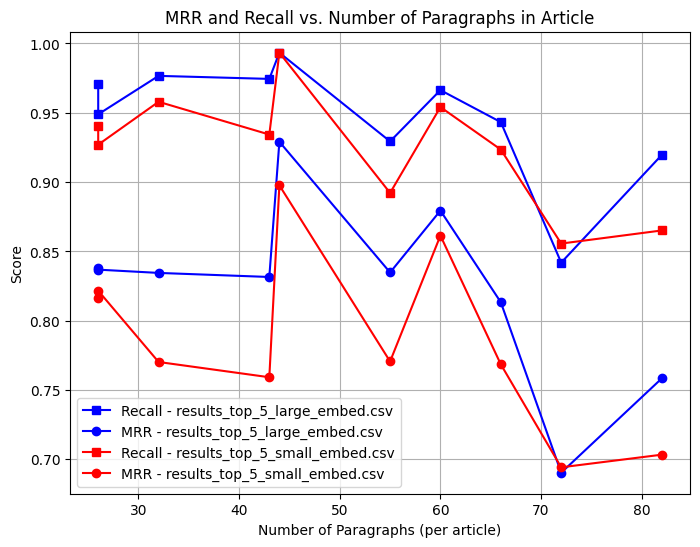

In [18]:
# compare small and large embeddings

# read the results
def print_results(data_set):
    results_df = pd.read_csv(f'{results_directory}/{data_set}')
    print(data_set)
    print(f"Number of questions: {len(results_df)}")
    print(f"Number of articles: {results_df['article'].nunique()}")
    mean_mrr = results_df['mrr'].mean()
    mean_recall = results_df['recall'].mean()
    print(f"Mean MRR: {mean_mrr:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print()


def results_by_article(data_set):
    results_df = pd.read_csv(f'{results_directory}/{data_set}')
    grouped = results_df.groupby('article').agg({
        'mrr': 'mean',
        'recall': 'mean',
        'question_id': 'count',
        'number_of_paragraphs': 'first'
    })
    grouped = grouped.rename(columns={'question_id': 'number_of_questions'})
    return grouped


def plot_results(data_sets):
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green', 'purple']  # assign each dataset a color
    for idx, ds in enumerate(data_sets):
        grouped = results_by_article(ds)
        grouped = grouped.sort_values('number_of_paragraphs')
        paragraphs = grouped['number_of_paragraphs']
        color = colors[idx % len(colors)]
        plt.plot(paragraphs, grouped['recall'], marker='s', color=color, label=f'Recall - {ds}')
        plt.plot(paragraphs, grouped['mrr'], marker='o', color=color, label=f'MRR - {ds}')
    plt.xlabel('Number of Paragraphs (per article)')
    plt.ylabel('Score')
    plt.title('MRR and Recall vs. Number of Paragraphs in Article')
    plt.grid(True)
    plt.legend()
    plt.show()


result_data = [
    "results_top_5_large_embed.csv",
    "results_top_5_small_embed.csv"
]

for data_set in result_data:
    print_results(data_set)

plot_results(result_data)